<a href="https://colab.research.google.com/github/nigusalene2-cyber/LiF-Mg-Cu-P-calibration/blob/main/project_on_dosimetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install required packages
!pip install -q openpyxl xgboost lightgbm catboost tensorflow plotly kaleido scipy

print("All packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 4.4 MB/s eta 0:00:00
All packages installed successfully!


In [ ]:
# Cell 2: Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
import os
import glob
from datetime import datetime
import json
import pickle
import io

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Setup plotting
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 3: Upload the Excel file
from google.colab import files

print("Please upload your Excel file (wielicka and NaCl at different doses (1).xlsx)")
print("Click the 'Choose Files' button below and select your file.")

uploaded = files.upload()

# Get the filename
file_name = list(uploaded.keys())[0] if uploaded else None

if file_name:
    print(f"\n✅ File '{file_name}' uploaded successfully!")
    print(f"File size: {len(uploaded[file_name]) / 1024:.2f} KB")
else:
    print("❌ No file uploaded. Please upload the Excel file.")

Please upload your Excel file (wielicka and NaCl at different doses (1).xlsx)
Click the 'Choose Files' button below and select your file.


Saving wielicka and NaCl at different doses (1).xlsx to wielicka and NaCl at different doses (1) (2).xlsx

✅ File 'wielicka and NaCl at different doses (1) (2).xlsx' uploaded successfully!
File size: 1447.92 KB


In [ ]:
# Cell 4: Load and preprocess data
import re
import numpy as np # Ensure numpy is imported
import pandas as pd # Ensure pandas is imported

def load_and_parse_data(file_path):
    """
    Load and parse the dosimetry data from Excel file
    """
    print("Loading data...")

    # Load Excel file
    xls = pd.ExcelFile(file_path)
    sheets = xls.sheet_names

    print(f"Found {len(sheets)} sheets: {sheets}")

    all_curves = []

    # Define where data for time and intensity columns usually starts
    data_start_row_idx = 8 # This is 0-indexed, so it refers to the 9th row

    for sheet_name in sheets:
        # Skip metadata sheets
        if sheet_name in ['Sheet7', 'Sheet8']:
            continue

        print(f"\nProcessing sheet: {sheet_name}")

        # Load sheet
        df = pd.read_excel(xls, sheet_name=sheet_name, header=None)

        # Determine material and LED condition from sheet name
        material = 'Wielicka' if 'Wielicka' in sheet_name else 'NaCl'
        led_condition = 'With LED' if 'LED 1' in sheet_name else 'No LED'

        # --- Dynamic Header Row Identification (Revised: Plausible Doses) ---
        best_header_row_idx = -1
        max_plausible_doses = 0

        # Search within rows 0 to data_start_row_idx - 1 (i.e., rows 0-7)
        search_rows_end = min(data_start_row_idx, df.shape[0])
        for r_idx in range(search_rows_end):
            current_row = df.iloc[r_idx]
            plausible_doses_count = 0
            # Skip first two columns when checking for plausible doses, as they are often metadata
            for col_val in current_row.iloc[2:]:
                try:
                    num_val = float(str(col_val).replace(',', '.'))
                    # A plausible dose is generally non-negative and not excessively large (e.g., < 2000 Gy)
                    if not np.isnan(num_val) and num_val >= 0 and num_val < 2000:
                        plausible_doses_count += 1
                except ValueError:
                    pass # Not a number

            # Prioritize rows with more plausible doses
            # Require at least 2 plausible doses to consider it a header row
            if plausible_doses_count >= 2 and plausible_doses_count > max_plausible_doses:
                max_plausible_doses = plausible_doses_count
                best_header_row_idx = r_idx

        if best_header_row_idx == -1:
            print(f"  Could not find a suitable header row with plausible doses in sheet '{sheet_name}'. Skipping.")
            continue

        header_row = df.iloc[best_header_row_idx]
        print(f"  Identified header row {best_header_row_idx} for '{sheet_name}' based on plausible doses:\n{header_row.to_string()}") # Debugging print

        # Find data columns (columns with dose information)
        for col_idx, header in enumerate(header_row):
            dose = None

            # Skip the first two columns (index 0 and 1) as they are usually metadata/summary
            if col_idx < 2:
                print(f"  Column {col_idx}: Skipping header '{header}' (metadata/summary column).")
                continue

            # Attempt to convert header directly to a float (e.g., if header is '0.5' or '1')
            try:
                num_val = float(str(header).replace(',', '.'))
                # Check if it's a plausible dose (non-NaN, non-negative, and not excessively large)
                if not np.isnan(num_val) and num_val >= 0 and num_val < 2000: # Upper bound 2000 Gy
                    dose = num_val
                else:
                    # If it's a number but outside plausible dose range, skip.
                    print(f"  Column {col_idx}: Skipping header '{header}' (numerical value outside plausible dose range).")
                    continue
            except ValueError:
                pass # Not a direct number, try regex for 'Gy'

            # If not a direct number, try to extract dose from 'Gy' pattern
            if dose is None and isinstance(header, str) and ('Gy' in header or 'Gy' in str(header)):
                print(f"  Column {col_idx}: Found 'Gy' in header '{header}'") # Debugging print
                try:
                    # Extract dose
                    dose_str_part = header.split('Gy')[0].strip()
                    # Try to extract number, allowing for comma as decimal separator
                    dose_match = re.search(r'([\d,\.]+)', dose_str_part)
                    if dose_match:
                        extracted_dose = float(dose_match.group(1).replace(',', '.'))
                        if extracted_dose >= 0 and extracted_dose < 2000: # Check plausible range again
                            dose = extracted_dose
                            print(f"    Extracted dose: {dose} from '{header}'") # Debugging print
                        else:
                             print(f"    Extracted dose: {extracted_dose} from '{header}' is outside plausible range. Skipping.")
                    else:
                        print(f"    Could not extract dose number from '{header}'. Skipping column {col_idx}.")
                        continue
                except Exception as e:
                    print(f"  ❌ Error parsing 'Gy' header '{header}' in sheet '{sheet_name}': {e}. Skipping column {col_idx}.")
                    continue

            if dose is None: # If dose is still None after all attempts, skip this column
                print(f"  Column {col_idx}: Skipping header '{header}' (No recognizable dose pattern found).")
                continue

            # Extract data
            # Check if df has enough rows for data_start_row_idx
            if df.shape[0] < data_start_row_idx + 1:
                print(f"    Sheet {sheet_name} has insufficient rows for data starting at index {data_start_row_idx}. Skipping column {col_idx}.")
                continue

            # Ensure data extraction starts from the correct row index after identifying headers
            # The actual data should start below the identified header row and any other metadata
            # Assuming time is consistently in column B (index 1) and data starts at row 9 (index 8)
            actual_data_start = max(data_start_row_idx, best_header_row_idx + 1) # Ensure we start below the identified header

            data_col = df.iloc[actual_data_start:, col_idx].values
            time_col = df.iloc[actual_data_start:, 1].values  # Time is in column B (index 1)

            # Clean data
            # Convert to numeric, coercing errors to NaN, before checking for NaNs
            time_numeric = pd.to_numeric(time_col, errors='coerce')
            data_numeric = pd.to_numeric(data_col, errors='coerce')

            mask = ~np.isnan(data_numeric) & ~np.isnan(time_numeric)
            if np.sum(mask) < 10:
                print(f"    Skipping column {col_idx} (header: '{header}', dose: {dose}) due to insufficient valid data points (<10 after cleaning). Found {np.sum(mask)} points.") # Debugging print
                continue

            time = time_numeric[mask].astype(float)
            intensity = data_numeric[mask].astype(float)

            # Store curve
            curve = {
                'material': material,
                'led_condition': led_condition,
                'dose': dose,
                'time': time,
                'intensity': intensity,
                'sheet': sheet_name
            }
            all_curves.append(curve)
            print(f"    ✅ Added curve for sheet '{sheet_name}', dose {dose} Gy, {len(time)} data points.") # Debugging print


    print(f"\n✅ Extracted {len(all_curves)} glow curves")
    return all_curves

# Load the data
glow_curves = load_and_parse_data(file_name)

# Show summary
print("\n" + "="*50)
print("DATA SUMMARY")
print("="*50)
materiais = [c['material'] for c in glow_curves]
doses = [c['dose'] for c in glow_curves]

print(f"Total curves: {len(glow_curves)}")
print(f"Materials: {set(materiais)}")
# Add a check before attempting to get min/max of doses
if doses: # This is the main fix for the ValueError
    print(f"Dose range: {min(doses):.3f} to {max(doses):.3f} Gy")
    print(f"Unique doses: {sorted(set(doses))}")
else:
    print("Dose range: No doses found (empty 'doses' list)")
    print("Unique doses: No unique doses found (empty 'doses' list)")

print(f"LED conditions: {set([c['led_condition'] for c in glow_curves])}")

Loading data...
Found 5 sheets: ['Wielicka LED 0', 'Sheet7', 'Wielicka LED 1', 'NaCl LED 0', 'NaCl LED 1']

Processing sheet: Wielicka LED 0
  Identified header row 6 for 'Wielicka LED 0' based on plausible doses:
0     with background
1                 NaN
2             1243681
3                 138
4                 NaN
5              317676
6                 550
7                 NaN
8              526306
9                1095
10                NaN
11            1243673
12               3100
13                NaN
14            2492910
15               8813
16                NaN
17             102997
18                105
19                NaN
20             262264
21                351
22                NaN
23             494688
24                969
25                NaN
26            1034116
27               2520
28                NaN
29            2531289
30               8730
31                NaN
32             120469
33                116
34                NaN
35             2

In [ ]:
# Cell 5: Extract features from glow curves
from scipy.signal import savgol_filter, find_peaks

def calculate_kinetic_parameters(time, intensity):
    """
    Calculate kinetic parameters from glow curve
    """
    try:
        peak_idx = np.argmax(intensity)
        if peak_idx == 0 or peak_idx == len(intensity) - 1:
            return {}

        Tm = time[peak_idx]
        Imax = intensity[peak_idx]

        # Find FWHM
        half_max = Imax / 2
        left_indices = np.where(intensity[:peak_idx] <= half_max)[0]
        right_indices = np.where(intensity[peak_idx:] <= half_max)[0]

        if len(left_indices) == 0 or len(right_indices) == 0:
            return {}

        T1 = time[left_indices[-1]]
        T2 = time[peak_idx + right_indices[0]]

        # Symmetry factor
        delta = T2 - T1
        omega = T2 - T1
        mu_g = delta / omega if omega > 0 else 0.5
        fwhm = T2 - T1

        # Estimate activation energy (Chen's method)
        k = 8.617e-5
        E = 1.0 # Default value
        if fwhm > 0 and Tm > 0: # Ensure Tm is not zero for E calculation
            E = 2.52 * T1 * T2 / (Tm * fwhm)

        # Estimate frequency factor
        s = 1e10 # Default value
        if E > 0 and Tm > 0: # Ensure E and Tm are positive
            # Cap the argument to np.exp to prevent infinity
            exp_arg = E / (k * Tm)
            # Use a slightly lower cap (1e20) for s_chen, as np.finfo(np.float64).max can still cause issues with RobustScaler
            if exp_arg > np.log(1e20 / ((1.0 * E) / (k * Tm**2)) + 1e-10): # Prevent overflow to 1e20
                s = 1e20 # Cap s at 1e20
            else:
                s = (1.0 * E) / (k * Tm**2) * np.exp(exp_arg)
                # Further cap s if it still becomes inf due to intermediate calculations or exceeds 1e20
                if np.isinf(s) or s > 1e20:
                    s = 1e20

        return {
            'Tm': Tm,
            'Imax': Imax,
            'T1': T1,
            'T2': T2,
            'fwhm': fwhm,
            'mu_g': mu_g,
            'E_chen': E,
            's_chen': s
        }
    except Exception as e:
        # print(f"Error in kinetic parameter calculation: {e}") # For debugging if needed
        return {}

def extract_features(curve):
    """
    Extract comprehensive features from a glow curve
    """
    time = curve['time']
    intensity = curve['intensity']

    features = {
        'material': curve['material'],
        'led_condition': curve['led_condition'],
        'dose': curve['dose']
    }

    # 1. Basic features
    features['total_integral'] = np.trapz(intensity, time)
    features['max_intensity'] = np.max(intensity)
    features['mean_intensity'] = np.mean(intensity)
    features['std_intensity'] = np.std(intensity)
    features['min_intensity'] = np.min(intensity)

    # 2. Time-binned integrals
    bins = [(0, 5), (5, 10), (10, 20), (20, 30), (30, 45), (45, 60)]
    for start, end in bins:
        mask = (time >= start) & (time < end)
        if np.sum(mask) > 0:
            integral = np.trapz(intensity[mask], time[mask])
            features[f'integral_{start}_{end}'] = integral
        else:
            features[f'integral_{start}_{end}'] = 0

    # 3. Ratio features
    total = features['total_integral'] + 1e-10
    for start, end in bins:
        key = f'integral_{start}_{end}'
        features[f'ratio_{start}_{end}'] = features[key] / total

    # 4. Peak features
    try:
        if len(intensity) > 20: # Use 11 for window_length, 3 for polyorder based on common practice
            smoothed = savgol_filter(intensity, 11, 3, mode='nearest') # mode='nearest' to handle edges
        else:
            smoothed = intensity

        # Adjust height and distance parameters as needed for specific data
        peaks, props = find_peaks(smoothed, height=np.max(smoothed)*0.1, distance=5)

        if len(peaks) > 0:
            main_peak_idx = peaks[np.argmax(props['peak_heights'])]
            features['peak_time'] = time[main_peak_idx]
            features['peak_intensity'] = intensity[main_peak_idx]
            features['num_peaks'] = len(peaks)

            if len(peaks) > 1:
                # Find the second highest peak, not necessarily the second in list
                peak_heights_sorted_idx = np.argsort(props['peak_heights'])[::-1]
                if len(peak_heights_sorted_idx) > 1:
                    second_peak_idx = peaks[peak_heights_sorted_idx[1]]
                    features['second_peak_ratio'] = intensity[second_peak_idx] / (intensity[main_peak_idx] + 1e-10)
                else:
                     features['second_peak_ratio'] = 0
            else:
                features['second_peak_ratio'] = 0
        else:
            # If no peaks are found by find_peaks, fall back to argmax
            features['peak_time'] = time[np.argmax(intensity)]
            features['peak_intensity'] = np.max(intensity)
            features['num_peaks'] = 0 # Explicitly 0 peaks if find_peaks found none
            features['second_peak_ratio'] = 0
    except Exception as e:
        # print(f"Error in peak feature extraction: {e}") # For debugging if needed
        features['peak_time'] = time[np.argmax(intensity)]
        features['peak_intensity'] = np.max(intensity)
        features['num_peaks'] = 1 # Assume one main peak in case of error
        features['second_peak_ratio'] = 0

    # 5. Shape features
    features['skewness'] = skew(intensity) if len(intensity) > 0 else 0
    features['kurtosis'] = kurtosis(intensity) if len(intensity) > 0 else 0

    # 6. Decay features
    mid_point = len(time) // 2
    if mid_point > 0 and np.mean(intensity[mid_point:]) > 0: # Ensure late_mean is not zero
        early_mean = np.mean(intensity[:mid_point])
        late_mean = np.mean(intensity[mid_point:])
        features['decay_ratio'] = early_mean / (late_mean + 1e-10)
    else:
        features['decay_ratio'] = 1

    # 7. Kinetic parameters
    kinetic_params = calculate_kinetic_parameters(time, intensity)
    for key, value in kinetic_params.items():
        features[key] = value

    # 8. Additional statistical features
    features['intensity_range'] = features['max_intensity'] - features['min_intensity']
    features['cv_intensity'] = features['std_intensity'] / (features['mean_intensity'] + 1e-10) # Add epsilon to avoid division by zero

    # 9. Percentiles
    for p in [10, 25, 50, 75, 90]:
        features[f'percentile_{p}'] = np.percentile(intensity, p) if len(intensity) > 0 else 0

    # 10. Peak width at half maximum (if not already calculated by kinetic parameters)
    if 'fwhm' not in features or features['fwhm'] == 0: # Recalculate if it was zero or not set
        half_max = np.max(intensity) / 2
        max_idx = np.argmax(intensity)
        # Ensure indices exist before accessing
        left_indices = np.where(intensity[:max_idx] <= half_max)[0]
        right_indices = np.where(intensity[max_idx:] <= half_max)[0]

        if len(left_indices) > 0 and len(right_indices) > 0:
            T1_fwhm = time[left_indices[-1]]
            T2_fwhm = time[max_idx + right_indices[0]]
            features['fwhm'] = T2_fwhm - T1_fwhm
        else:
            features['fwhm'] = 0

    # Ensure all kinetic parameters are present, fill with NaN if missing (e.g., from error in func)
    kinetic_param_keys = ['Tm', 'Imax', 'T1', 'T2', 'mu_g', 'E_chen', 's_chen']
    for kp_key in kinetic_param_keys:
        if kp_key not in features:
            features[kp_key] = np.nan

    return features

# Extract features from all glow curves
print("Extracting features...")
feature_list = []
for curve in glow_curves:
    features = extract_features(curve)
    feature_list.append(features)

# Create DataFrame
features_df = pd.DataFrame(feature_list)

# Encode categorical variables
features_df['material_encoded'] = features_df['material'].map({'Wielicka': 0, 'NaCl': 1})
features_df['led_encoded'] = features_df['led_condition'].map({'No LED': 0, 'With LED': 1})

print(f"\n✅ Feature matrix created: {features_df.shape}")
print(f"Features: {list(features_df.columns)}")

# Show first few rows
print("\nFirst few rows of feature matrix:")
display(features_df.head())

Extracting features...

✅ Feature matrix created: (80, 44)
Features: ['material', 'led_condition', 'dose', 'total_integral', 'max_intensity', 'mean_intensity', 'std_intensity', 'min_intensity', 'integral_0_5', 'integral_5_10', 'integral_10_20', 'integral_20_30', 'integral_30_45', 'integral_45_60', 'ratio_0_5', 'ratio_5_10', 'ratio_10_20', 'ratio_20_30', 'ratio_30_45', 'ratio_45_60', 'peak_time', 'peak_intensity', 'num_peaks', 'second_peak_ratio', 'skewness', 'kurtosis', 'decay_ratio', 'intensity_range', 'cv_intensity', 'percentile_10', 'percentile_25', 'percentile_50', 'percentile_75', 'percentile_90', 'fwhm', 'Tm', 'Imax', 'T1', 'T2', 'mu_g', 'E_chen', 's_chen', 'material_encoded', 'led_encoded']

First few rows of feature matrix:


,material,led_condition,dose,total_integral,max_intensity,mean_intensity,std_intensity,min_intensity,integral_0_5,integral_5_10,...,fwhm,Tm,Imax,T1,T2,mu_g,E_chen,s_chen,material_encoded,led_encoded
0,Wielicka,No LED,138.0,410.65,21.0,6.858333,4.049889,0.0,71.0,58.80,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,Wielicka,No LED,550.0,1362.70,65.0,22.768333,12.700840,5.0,240.3,193.05,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,Wielicka,No LED,1095.0,4544.70,177.0,75.890000,35.225245,25.0,709.8,615.35,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,Wielicka,No LED,105.0,416.95,21.0,6.961667,3.694617,0.0,64.1,55.00,...,1.3,1.7,21.0,1.4,2.7,1.0,4.310226,1.000000e+20,0,0
4,Wielicka,No LED,351.0,1455.50,61.0,24.308333,12.308937,6.0,234.8,205.70,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


Creating visualizations...


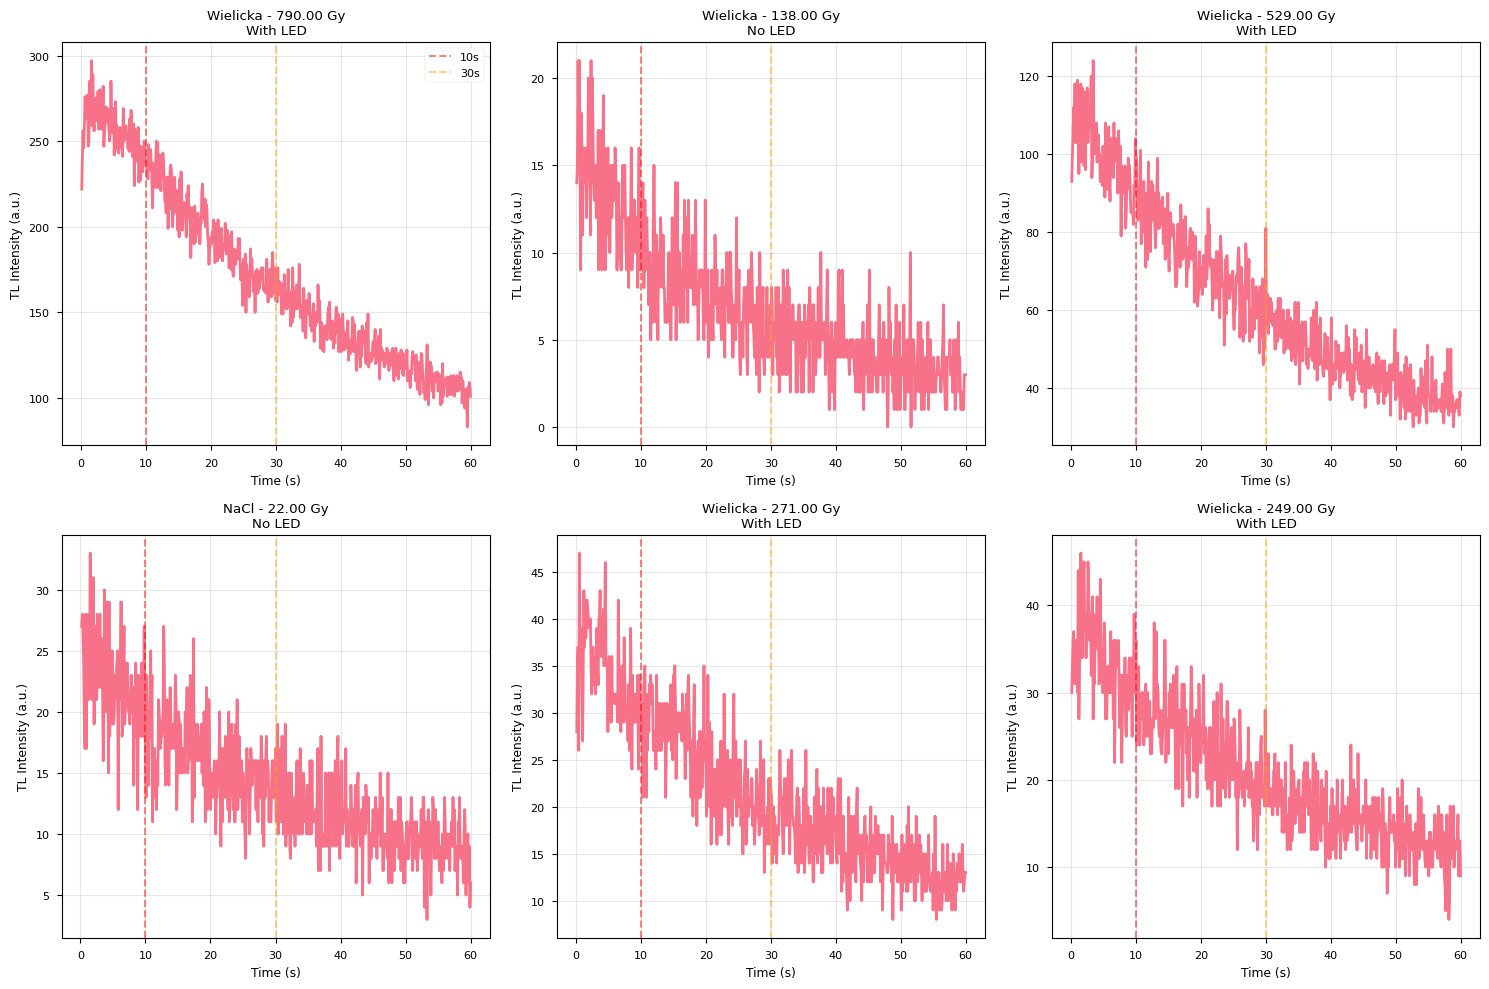

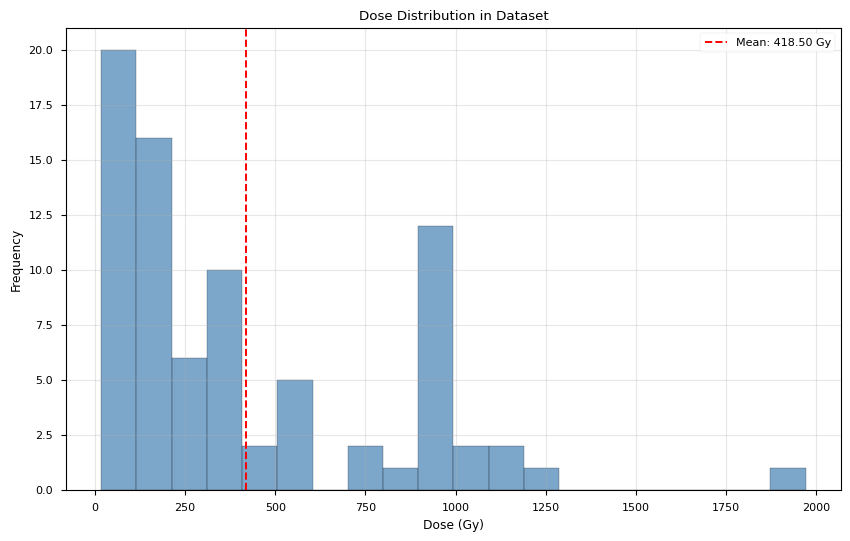

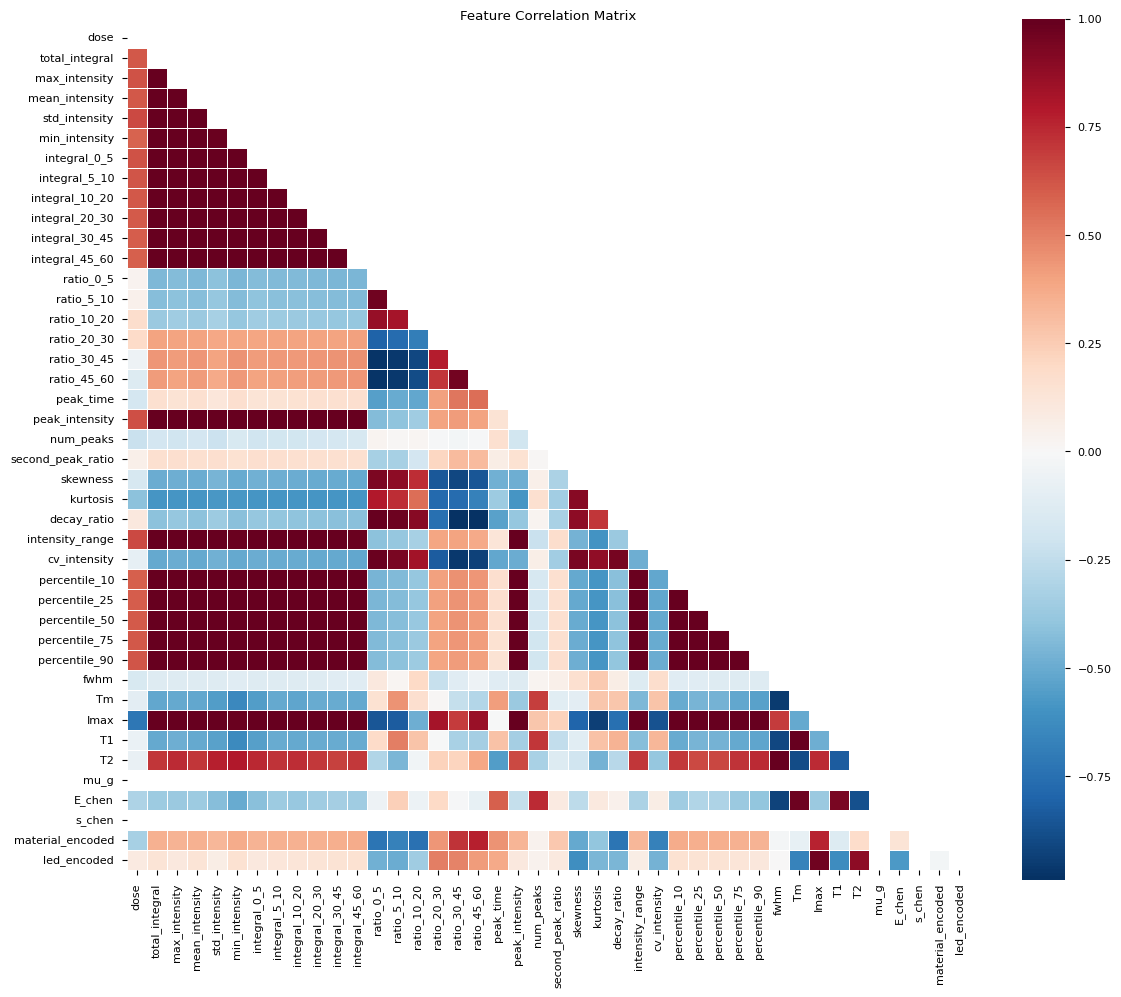

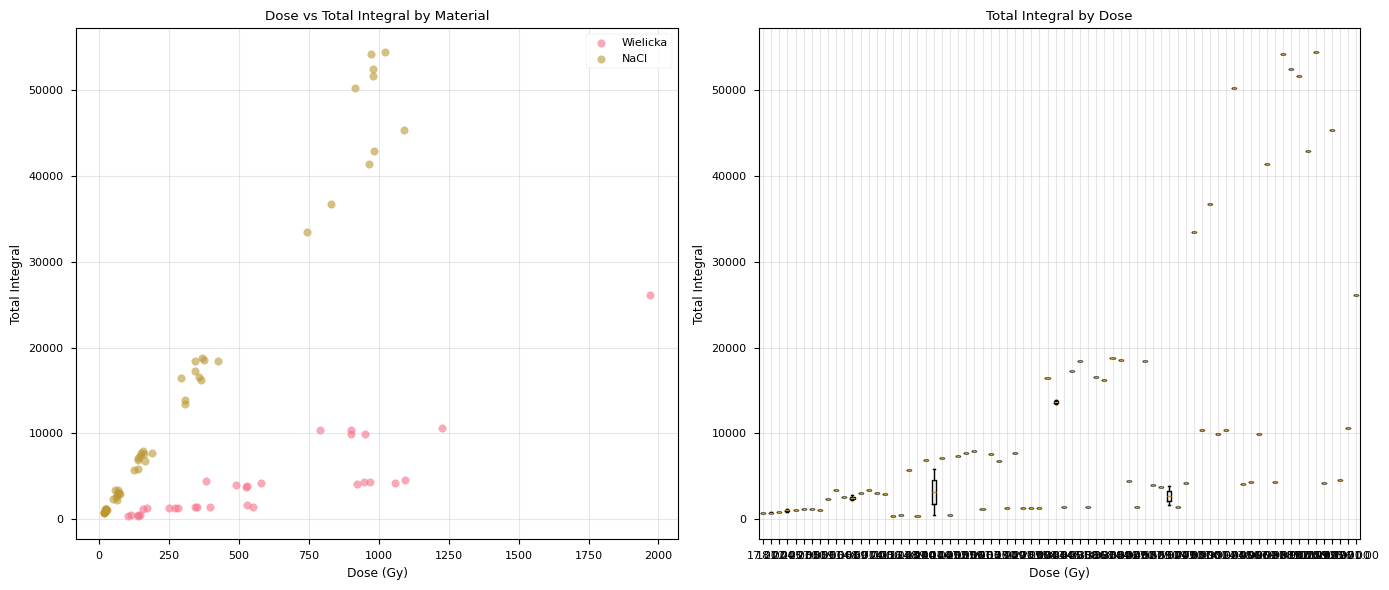

✅ Visualizations complete!


In [ ]:
# Cell 6: Visualize glow curves and features
print("Creating visualizations...")

# 1. Sample glow curves
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Select sample curves
sample_indices = np.random.choice(len(glow_curves), min(6, len(glow_curves)), replace=False)

for idx, ax in enumerate(axes[:len(sample_indices)]):
    curve = glow_curves[sample_indices[idx]]
    ax.plot(curve['time'], curve['intensity'], linewidth=2)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('TL Intensity (a.u.)')
    ax.set_title(f"{curve['material']} - {curve['dose']:.2f} Gy\n{curve['led_condition']}")
    ax.grid(True, alpha=0.3)
    ax.axvline(10, color='red', linestyle='--', alpha=0.5, label='10s')
    ax.axvline(30, color='orange', linestyle='--', alpha=0.5, label='30s')
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

# 2. Dose distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(features_df['dose'], bins=20, alpha=0.7, edgecolor='black', color='steelblue')
ax.set_xlabel('Dose (Gy)')
ax.set_ylabel('Frequency')
ax.set_title('Dose Distribution in Dataset')
ax.grid(True, alpha=0.3)
ax.axvline(features_df['dose'].mean(), color='red', linestyle='--',
           label=f"Mean: {features_df['dose'].mean():.2f} Gy")
ax.legend()
plt.show()

# 3. Feature correlation matrix
numeric_cols = features_df.select_dtypes(include=[np.number]).columns
corr_matrix = features_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# 4. Material comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

materials = features_df['material'].unique()
for idx, material in enumerate(materials):
    subset = features_df[features_df['material'] == material]
    axes[0].scatter(subset['dose'], subset['total_integral'],
                   alpha=0.6, label=material, s=30)
axes[0].set_xlabel('Dose (Gy)')
axes[0].set_ylabel('Total Integral')
axes[0].set_title('Dose vs Total Integral by Material')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by dose
dose_groups = features_df.groupby('dose')['total_integral'].apply(list)
dose_labels = [f"{d:.2f}" for d in sorted(features_df['dose'].unique())]
axes[1].boxplot([dose_groups[d] for d in sorted(dose_groups.keys())],
                labels=dose_labels, showfliers=False)
axes[1].set_xlabel('Dose (Gy)')
axes[1].set_ylabel('Total Integral')
axes[1].set_title('Total Integral by Dose')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations complete!")

In [ ]:
# Cell 7: Prepare data for machine learning
print("Preparing data for machine learning...")

# Select features
exclude_cols = ['material', 'led_condition', 'dose', 'material_encoded', 'led_encoded']
feature_cols = []

for col in features_df.columns:
    if col not in exclude_cols and pd.api.types.is_numeric_dtype(features_df[col]):
        feature_cols.append(col)

print(f"\nSelected {len(feature_cols)} features")
print(f"Features: {feature_cols[:10]}...")

# Prepare X and y
X = features_df[feature_cols].copy()
y = features_df['dose'].copy()

# Remove NaN values
valid_mask = ~(X.isna().any(axis=1) | y.isna())
X = X[valid_mask]
y = y[valid_mask]

print(f"\nFinal dataset: {len(X)} samples, {X.shape[1]} features")
print(f"Dose range: {y.min():.3f} to {y.max():.3f} Gy")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data prepared for machine learning!")

Preparing data for machine learning...

Selected 39 features
Features: ['total_integral', 'max_intensity', 'mean_intensity', 'std_intensity', 'min_intensity', 'integral_0_5', 'integral_5_10', 'integral_10_20', 'integral_20_30', 'integral_30_45']...

Final dataset: 4 samples, 39 features
Dose range: 18.000 to 140.000 Gy

Training set: 3 samples
Test set: 1 samples

✅ Data prepared for machine learning!


In [ ]:
# Cell 8: Train and evaluate machine learning models
print("Training machine learning models...")
print("="*60)

# Define models
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=15,
        min_samples_split=5, random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, max_depth=5,
        learning_rate=0.1, random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100, max_depth=5,
        learning_rate=0.1, random_state=42
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100, max_depth=5,
        learning_rate=0.1, random_state=42,
        verbose=-1
    ),
    'Neural Network': MLPRegressor(
        hidden_layer_sizes=(100, 50, 25),
        activation='relu', max_iter=500,
        random_state=42
    )
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Metrics
    train_mae = mean_absolute_error(y_train, y_pred_train)
    train_r2 = r2_score(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)

    results[name] = {
        'model': model,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'test_mae': test_mae,
        'test_r2': test_r2,
        'y_pred_test': y_pred_test
    }

    print(f"  Train MAE: {train_mae:.3f} Gy, R2: {train_r2:.3f}")
    print(f"  Test MAE: {test_mae:.3f} Gy, R2: {test_r2:.3f}")

# Find best model
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
best_model = results[best_model_name]['model']

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"Test R2: {results[best_model_name]['test_r2']:.3f}")
print(f"Test MAE: {results[best_model_name]['test_mae']:.3f} Gy")
print("="*60)

Training machine learning models...

Training Random Forest...
  Train MAE: 36.632 Gy, R2: -0.001
  Test MAE: 92.103 Gy, R2: nan

Training Gradient Boosting...
  Train MAE: 0.001 Gy, R2: 1.000
  Test MAE: 50.575 Gy, R2: nan

Training XGBoost...
  Train MAE: 0.183 Gy, R2: 1.000
  Test MAE: 35.330 Gy, R2: nan

Training LightGBM...
  Train MAE: 37.111 Gy, R2: 0.000
  Test MAE: 90.667 Gy, R2: nan

Training Neural Network...
  Train MAE: 4.885 Gy, R2: 0.971
  Test MAE: 32.590 Gy, R2: nan

🏆 BEST MODEL: Random Forest
Test R2: nan
Test MAE: 92.103 Gy


Visualizing model performance...


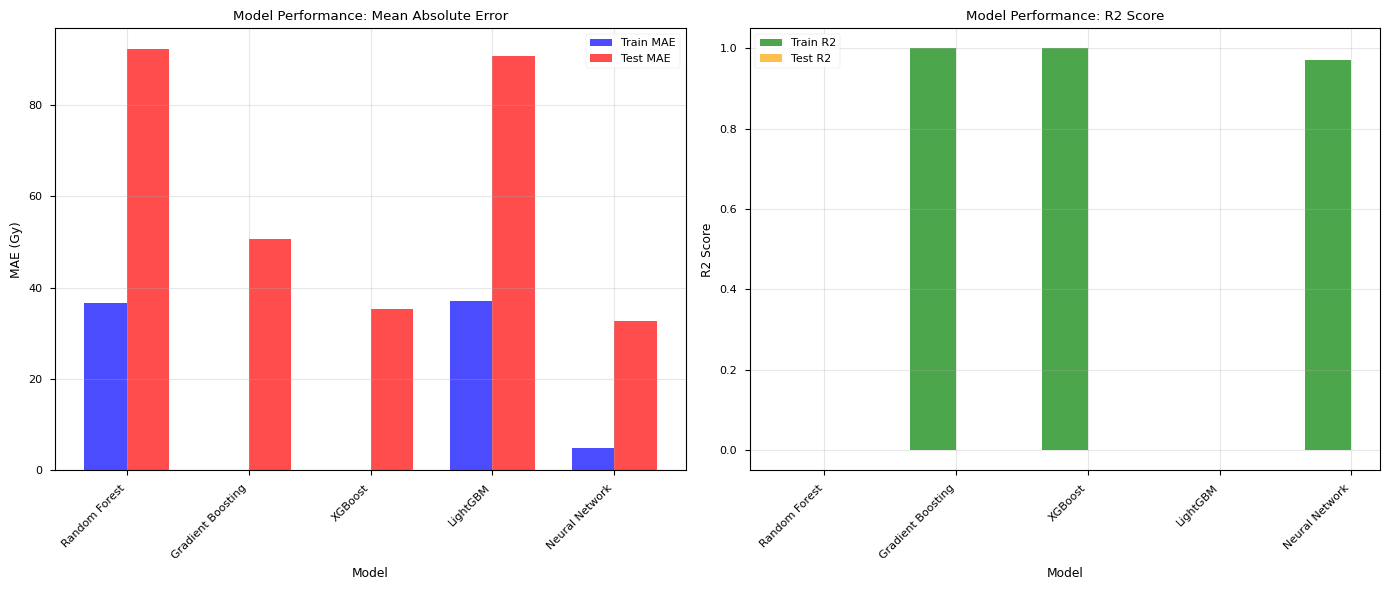

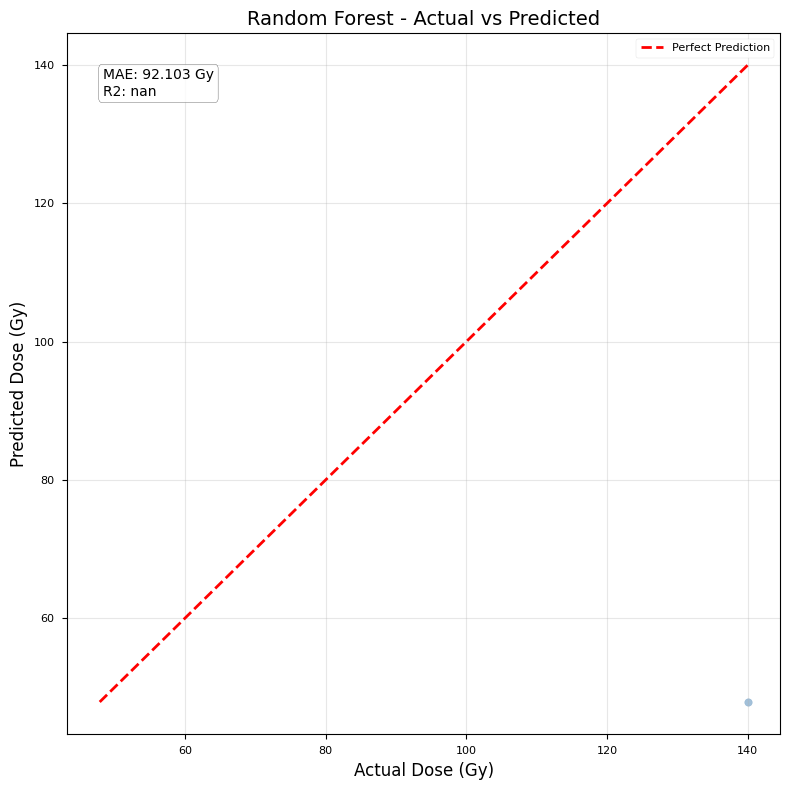

✅ Visualization complete!


In [ ]:
# Cell 9: Visualize model performance
print("Visualizing model performance...")

# 1. Performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_names = list(results.keys())
train_mae = [results[m]['train_mae'] for m in model_names]
test_mae = [results[m]['test_mae'] for m in model_names]
train_r2 = [results[m]['train_r2'] for m in model_names]
test_r2 = [results[m]['test_r2'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

# MAE plot
ax = axes[0]
ax.bar(x - width/2, train_mae, width, label='Train MAE', color='blue', alpha=0.7)
ax.bar(x + width/2, test_mae, width, label='Test MAE', color='red', alpha=0.7)
ax.set_xlabel('Model')
ax.set_ylabel('MAE (Gy)')
ax.set_title('Model Performance: Mean Absolute Error')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

# R2 plot
ax = axes[1]
ax.bar(x - width/2, train_r2, width, label='Train R2', color='green', alpha=0.7)
ax.bar(x + width/2, test_r2, width, label='Test R2', color='orange', alpha=0.7)
ax.set_xlabel('Model')
ax.set_ylabel('R2 Score')
ax.set_title('Model Performance: R2 Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Actual vs Predicted for best model
fig, ax = plt.subplots(figsize=(8, 8))

y_pred = results[best_model_name]['y_pred_test']
ax.scatter(y_test, y_pred, alpha=0.5, s=30, color='steelblue')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Dose (Gy)', fontsize=12)
ax.set_ylabel('Predicted Dose (Gy)', fontsize=12)
ax.set_title(f'{best_model_name} - Actual vs Predicted', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

# Add metrics
mae = results[best_model_name]['test_mae']
r2 = results[best_model_name]['test_r2']
text = f'MAE: {mae:.3f} Gy\nR2: {r2:.3f}'
ax.text(0.05, 0.95, text, transform=ax.transAxes,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

Analyzing feature importance...

Top 15 Most Important Features:
           feature  importance
0   total_integral         0.0
1    max_intensity         0.0
2   mean_intensity         0.0
3    std_intensity         0.0
4    min_intensity         0.0
5     integral_0_5         0.0
6    integral_5_10         0.0
7   integral_10_20         0.0
8   integral_20_30         0.0
9   integral_30_45         0.0
10  integral_45_60         0.0
11       ratio_0_5         0.0
12      ratio_5_10         0.0
13     ratio_10_20         0.0
14     ratio_20_30         0.0


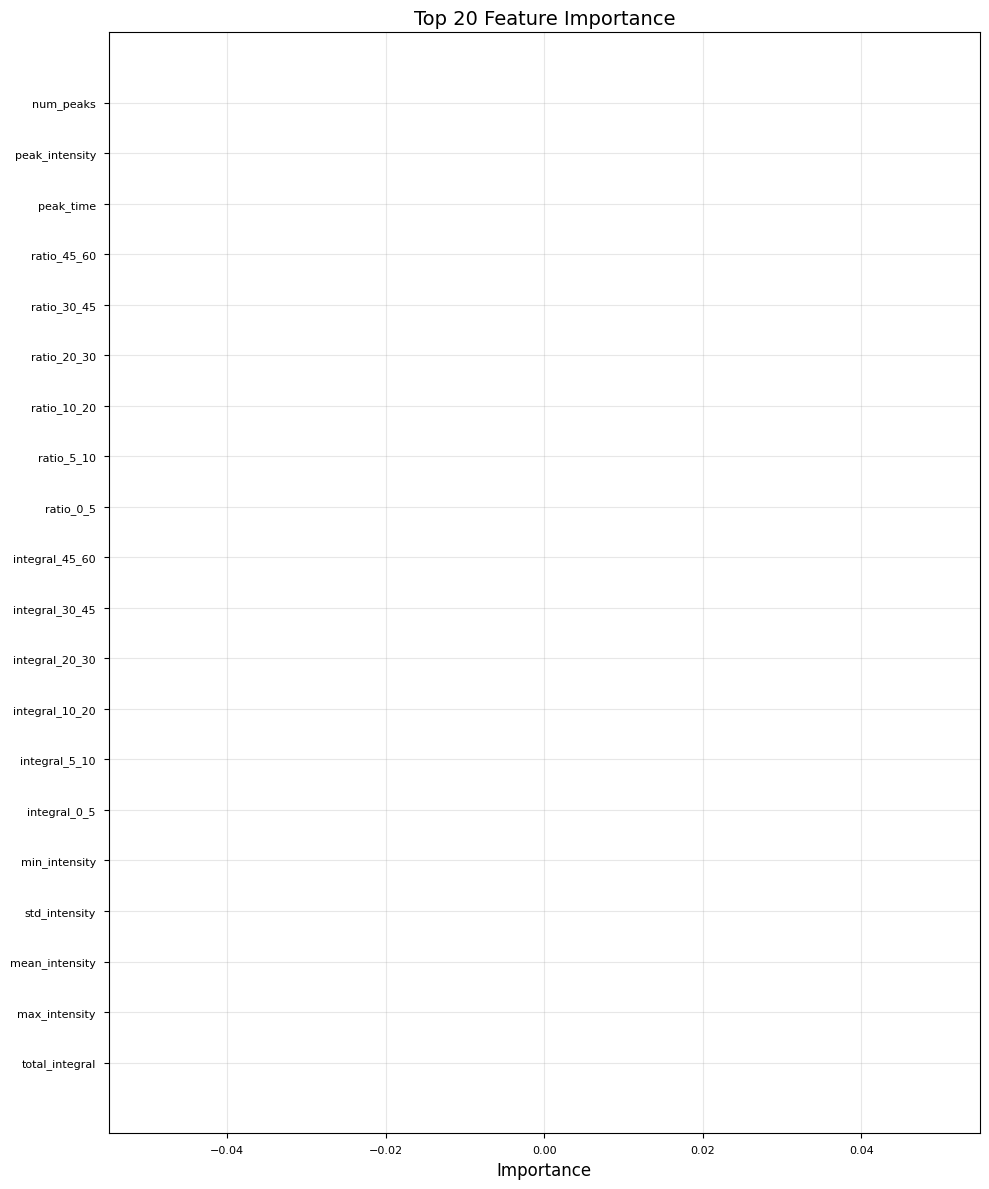


✅ Feature importance analysis complete!


In [ ]:
# Cell 10: Feature importance analysis
print("Analyzing feature importance...")

# Get feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_)
else:
    print("Model doesn't have feature importance attribute")
    importances = np.ones(len(feature_cols))

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15))

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 12))

top_n = 20
top_features = importance_df.head(top_n)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features)))[::-1]
bars = ax.barh(top_features['feature'], top_features['importance'], color=colors)

ax.set_xlabel('Importance', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importance', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Feature importance analysis complete!")

In [ ]:
# Cell 11: Hyperparameter tuning for best model (optional)
print("Performing hyperparameter tuning...")

# Prepare data
X_scaled = scaler.transform(X)

# Define parameter grid based on best model
if best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0]
    }
    model = xgb.XGBRegressor(random_state=42)
elif best_model_name == 'LightGBM':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'num_leaves': [31, 63, 127]
    }
    model = lgb.LGBMRegressor(random_state=42, verbose=-1)
else:
    print("Skipping hyperparameter tuning - not applicable for this model")
    param_grid = None

if param_grid:
    # Grid search
    grid_search = GridSearchCV(
        model, param_grid, cv=3,
        scoring='r2', n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_scaled, y)

    print(f"\nBest parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.3f}")

    # Test optimized model
    optimized_model = grid_search.best_estimator_
    y_pred_opt = optimized_model.predict(X_test_scaled)

    opt_mae = mean_absolute_error(y_test, y_pred_opt)
    opt_r2 = r2_score(y_test, y_pred_opt)

    print(f"\nOptimized model performance:")
    print(f"  MAE: {opt_mae:.3f} Gy")
    print(f"  R2: {opt_r2:.3f}")

    # Compare with original
    print(f"\nImprovement:")
    print(f"  MAE: {results[best_model_name]['test_mae']:.3f} -> {opt_mae:.3f} Gy")
    print(f"  R2: {results[best_model_name]['test_r2']:.3f} -> {opt_r2:.3f}")

    # Update best model
    best_model = optimized_model

Performing hyperparameter tuning...
Skipping hyperparameter tuning - not applicable for this model


In [ ]:
# Cell 12: Save model and results
print("Saving model and results...")

# Create results directory
!mkdir -p results models

# 1. Save model
import joblib

joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Model saved to 'models/best_model.pkl'")

# 2. Save feature importance
importance_df.to_csv('results/feature_importance.csv', index=False)

# 3. Save model results
results_df = pd.DataFrame([
    {
        'Model': name,
        'Train MAE': results[name]['train_mae'],
        'Train R2': results[name]['train_r2'],
        'Test MAE': results[name]['test_mae'],
        'Test R2': results[name]['test_r2']
    }
    for name in results.keys()
])
results_df.to_csv('results/model_results.csv', index=False)

print("✅ Results saved to 'results/' directory")

# 4. Create summary report
with open('results/summary_report.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("EMERGENCY DOSIMETRY PROJECT - SUMMARY REPORT\n")
    f.write("="*60 + "\n\n")

    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

    f.write("DATASET SUMMARY:\n")
    f.write("-"*40 + "\n")
    f.write(f"Total glow curves: {len(glow_curves)}\n")
    f.write(f"Feature matrix: {features_df.shape}\n")
    f.write(f"Materials: {set(features_df['material'])}\n")
    f.write(f"Dose range: {features_df['dose'].min():.2f} - {features_df['dose'].max():.2f} Gy\n\n")

    f.write("MODEL PERFORMANCE:\n")
    f.write("-"*40 + "\n")
    for name, result in results.items():
        f.write(f"\n{name}:\n")
        f.write(f"  Test MAE: {result['test_mae']:.4f} Gy\n")
        f.write(f"  Test R2:  {result['test_r2']:.4f}\n")

    f.write(f"\nBEST MODEL: {best_model_name}\n")
    f.write(f"Best Test R2: {results[best_model_name]['test_r2']:.4f}\n")
    f.write(f"Best Test MAE: {results[best_model_name]['test_mae']:.4f} Gy\n\n")

    f.write("TOP 10 FEATURES:\n")
    f.write("-"*40 + "\n")
    for idx, row in importance_df.head(10).iterrows():
        f.write(f"{row['feature']}: {row['importance']:.4f}\n")

    f.write("\n" + "="*60 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*60 + "\n")

print("✅ Summary report saved to 'results/summary_report.txt'")

# Download results as zip
!zip -r emergency_dosimetry_results.zip results/ models/

print("\n✅ Results packaged in 'emergency_dosimetry_results.zip'")

# Download the results
from google.colab import files
files.download('emergency_dosimetry_results.zip')

print("\n🎉 All done! The results have been downloaded.")

Saving model and results...
✅ Model saved to 'models/best_model.pkl'
✅ Results saved to 'results/' directory
✅ Summary report saved to 'results/summary_report.txt'
  adding: results/ (stored 0%)
  adding: results/summary_report.txt (deflated 64%)
  adding: results/model_results.csv (deflated 37%)
  adding: results/feature_importance.csv (deflated 64%)
  adding: models/ (stored 0%)
  adding: models/scaler.pkl (deflated 39%)
  adding: models/best_model.pkl (deflated 95%)

✅ Results packaged in 'emergency_dosimetry_results.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 All done! The results have been downloaded.


In [ ]:
# Cell 13: Function for making predictions on new data
def predict_dose(time, intensity, model=best_model, scaler=scaler):
    """
    Predict dose from a new glow curve
    """
    # Create a curve dictionary
    curve = {
        'time': time,
        'intensity': intensity,
        'material': 'Unknown',
        'led_condition': 'Unknown',
        'dose': 0
    }

    # Extract features
    features = extract_features(curve)

    # Create DataFrame
    feature_df = pd.DataFrame([features])

    # Select only the features used in training
    X_new = feature_df[feature_cols].copy()

    # Handle NaN values
    X_new = X_new.fillna(0)

    # Scale
    X_new_scaled = scaler.transform(X_new)

    # Predict
    dose_pred = model.predict(X_new_scaled)[0]

    return dose_pred

# Example: Make a prediction on a test curve
print("Testing prediction function...")
test_curve = glow_curves[0]
predicted_dose = predict_dose(test_curve['time'], test_curve['intensity'])
actual_dose = test_curve['dose']

print(f"Actual dose: {actual_dose:.3f} Gy")
print(f"Predicted dose: {predicted_dose:.3f} Gy")
print(f"Error: {abs(predicted_dose - actual_dose):.3f} Gy")

print("\n✅ Prediction function ready for use!")

Testing prediction function...
Actual dose: 138.000 Gy
Predicted dose: 47.897 Gy
Error: 90.103 Gy

✅ Prediction function ready for use!


In [ ]:
# Cell 14: Create interactive dashboard
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

print("Creating interactive dashboard...")

# Create sample data for dashboard
sample_curves = glow_curves[:5]

# Create subplots
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Glow Curves', 'Dose Distribution',
                    'Material Comparison', 'Model Performance')
)

# 1. Glow curves
for curve in sample_curves:
    fig.add_trace(
        go.Scatter(
            x=curve['time'],
            y=curve['intensity'],
            name=f"{curve['material']} - {curve['dose']:.2f} Gy",
            line=dict(width=2)
        ),
        row=1, col=1
    )

# 2. Dose distribution
doses = [c['dose'] for c in glow_curves]
fig.add_trace(
    go.Histogram(x=doses, nbinsx=20, name='Dose Distribution'),
    row=1, col=2
)

# 3. Material comparison
for material in features_df['material'].unique():
    subset = features_df[features_df['material'] == material]
    fig.add_trace(
        go.Scatter(
            x=subset['dose'],
            y=subset['total_integral'],
            mode='markers',
            name=material,
            marker=dict(size=8, opacity=0.6)
        ),
        row=2, col=1
    )

# 4. Model performance
model_names = list(results.keys())
test_r2 = [results[m]['test_r2'] for m in model_names]
test_mae = [results[m]['test_mae'] for m in model_names]

fig.add_trace(
    go.Bar(
        x=model_names,
        y=test_r2,
        name='Test R2',
        marker_color='green'
    ),
    row=2, col=2
)

# Update layout
fig.update_layout(
    height=800,
    width=1200,
    showlegend=True,
    title_text="Emergency Dosimetry - Interactive Dashboard",
    title_font_size=20
)

# Show the dashboard
fig.show()

print("✅ Interactive dashboard created!")

Creating interactive dashboard...


✅ Interactive dashboard created!
